# Practical Notebook: Clustering with scikit-learn

This notebook is designed as a step-by-step practical section for the Clustering lecture.

- unsupervised learning works with data without target labels;
- clustering groups similar instances together;
- different algorithms capture different kinds of clusters;
- we will compare **K-Means**, **DBSCAN / optional HDBSCAN**, and **Agglomerative Hierarchical Clustering**;
- evaluation is harder than supervised learning, so we use internal and, only for teaching, external metrics.

> **Important:** When a dataset has true labels, we will **not** use them for fitting the clustering model. We use them only at the end to understand what happened.

## Learning outcomes

After completing this notebook, students should be able to:

1. prepare data for clustering with scaling and visualization;
2. apply K-Means and explain the role of `k`, centroids, inertia, and random initialization;
3. choose a reasonable `k` using the elbow method and silhouette score;
4. apply DBSCAN and understand `eps`, `min_samples`, and outlier labels;
5. apply Agglomerative Hierarchical Clustering and interpret a dendrogram;
6. evaluate clustering with silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, and NMI;
7. use clustering for practical tasks: segmentation, anomaly detection, semi-supervised learning, and image color segmentation.

## 0. Setup

Run the cell below first. It imports all required packages.

The notebook uses built-in scikit-learn datasets or dataset generators:

- `make_blobs`
- `make_moons`
- `make_circles`
- `load_iris`
- `load_digits`
- `load_sample_image`

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import (
    make_blobs,
    make_moons,
    make_circles,
    load_iris,
    load_digits,
    load_sample_image,
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

try:
    from sklearn.cluster import HDBSCAN
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("scikit-learn version:", sklearn.__version__)
print("HDBSCAN available in this scikit-learn installation:", HAS_HDBSCAN)

scikit-learn version: 1.6.1
HDBSCAN available in this scikit-learn installation: True


## 1. Helper functions for plotting and evaluation

These helper functions make the rest of the notebook easier to read.

In clustering, labels are arbitrary. For example, cluster `0` is not necessarily better or smaller than cluster `1`. The number is just an identifier.

In [2]:
def plot_2d_clusters(X, labels=None, centers=None, title="", xlabel="Feature 1", ylabel="Feature 2"):
    """Plot two-dimensional data with optional cluster labels and centers."""
    plt.figure(figsize=(7, 5))
    if labels is None:
        plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.8)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=25, cmap="tab10", alpha=0.8)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=240, edgecolor="black", linewidth=1.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()


def count_clusters(labels):
    """Return number of clusters, ignoring DBSCAN/HDBSCAN noise label -1."""
    labels = np.asarray(labels)
    return len(set(labels) - {-1})


def count_noise(labels):
    """Return number of noise / outlier points, where the label is -1."""
    labels = np.asarray(labels)
    return int(np.sum(labels == -1))


def safe_internal_metrics(X, labels):
    """Compute internal clustering metrics safely.

    Some metrics require at least two clusters and cannot handle the case where all points
    are assigned to one cluster or all points are marked as noise.
    """
    labels = np.asarray(labels)
    mask = labels != -1
    unique_clusters = set(labels[mask])
    n_clusters = len(unique_clusters)

    if n_clusters < 2 or np.sum(mask) <= n_clusters:
        return {
            "n_clusters_without_noise": n_clusters,
            "noise_points": count_noise(labels),
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    X_eval = X[mask]
    labels_eval = labels[mask]
    return {
        "n_clusters_without_noise": n_clusters,
        "noise_points": count_noise(labels),
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
    }


def clustering_report(X, labels, y_true=None, model_name="model"):
    """Return a one-row DataFrame with internal and optional external metrics."""
    row = safe_internal_metrics(X, labels)
    row["model"] = model_name
    if y_true is not None:
        row["adjusted_rand_index"] = adjusted_rand_score(y_true, labels)
        row["normalized_mutual_info"] = normalized_mutual_info_score(y_true, labels)
    return pd.DataFrame([row])

## 2. Create a first unlabeled dataset

We start with a simple synthetic dataset. It has four visible groups, but in a real unsupervised setting, we would only receive `X`, not the true group labels.

We scale the data because many clustering algorithms rely on distance. A feature with a large numeric range can dominate the distance calculation.

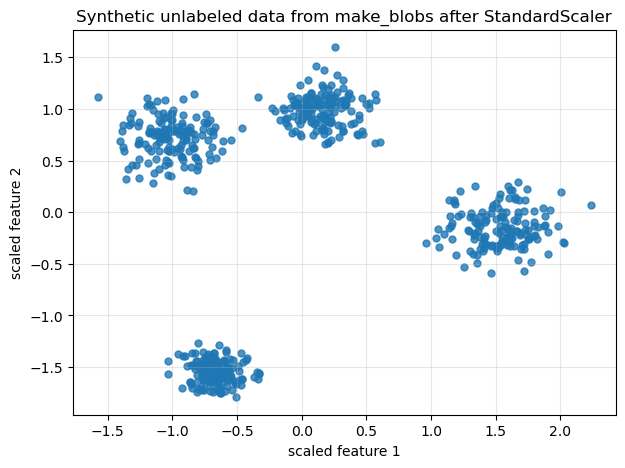

In [3]:
X_blobs, y_blobs_true = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=[1.0, 1.2, 0.7, 1.1],
    random_state=RANDOM_STATE,
)

scaler_blobs = StandardScaler()
X_blobs_scaled = scaler_blobs.fit_transform(X_blobs)

plot_2d_clusters(
    X_blobs_scaled,
    title="Synthetic unlabeled data from make_blobs after StandardScaler",
    xlabel="scaled feature 1",
    ylabel="scaled feature 2",
)

### Reflection

Before running a clustering algorithm, answer:

1. How many groups do you visually expect?
2. Are the groups round / compact or irregular?
3. Which algorithm do you expect to work well here: K-Means, DBSCAN, or Agglomerative Clustering?

## 3. K-Means: fit, predict, and inspect centroids

K-Means is centroid-based. It searches for `k` centroids and assigns each data point to the nearest centroid.

Key parameters:

- `n_clusters`: the number of clusters `k`;
- `n_init`: number of random initializations; more attempts reduce the risk of a poor local optimum;
- `random_state`: makes results reproducible for teaching.

Cluster labels for the first 20 samples:
[1 1 1 1 2 2 1 0 1 1 0 2 3 3 0 0 2 3 2 2]

Inertia: 37.0

Centroids:
[[ 0.16  0.99]
 [-0.67 -1.55]
 [ 1.53 -0.15]
 [-1.01  0.71]]


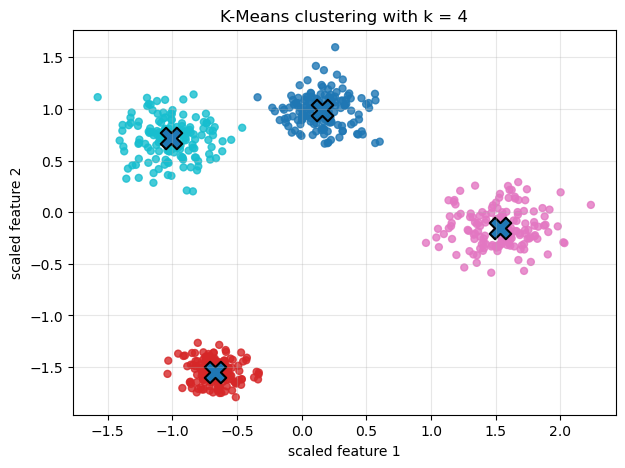

In [4]:
kmeans_4 = KMeans(n_clusters=4, n_init=5, max_iter=100, random_state=RANDOM_STATE)
labels_kmeans_4 = kmeans_4.fit_predict(X_blobs_scaled)

print("Cluster labels for the first 20 samples:")
print(labels_kmeans_4[:20])
print("\nInertia:", round(kmeans_4.inertia_, 2))
print("\nCentroids:")
print(np.round(kmeans_4.cluster_centers_, 2))

plot_2d_clusters(
    X_blobs_scaled,
    labels=labels_kmeans_4,
    centers=kmeans_4.cluster_centers_,
    title="K-Means clustering with k = 4",
    xlabel="scaled feature 1",
    ylabel="scaled feature 2",
)

### Interpret the output

- Each point receives a cluster id.
- The centroids are the learned cluster centers.
- Inertia is the sum of squared distances from each point to its nearest centroid.
- Lower inertia means points are closer to their assigned centroids, but inertia always tends to decrease when `k` increases.

## 4. Choosing `k`: elbow method

Because K-Means requires the number of clusters in advance, we need a practical way to choose `k`.

The elbow method runs K-Means for several values of `k` and plots inertia. We look for a point where improvement slows down.

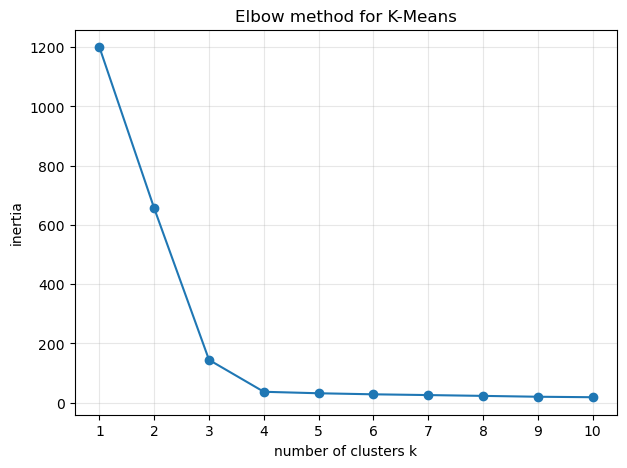

,k,inertia
0,1,1200.000000
1,2,656.009233
2,3,144.610714
3,4,36.999057
4,5,31.991239
5,6,28.452302
6,7,25.883451
7,8,23.143022
8,9,20.236834
9,10,18.626296


In [5]:
ks = range(1, 11)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k, n_init=5, max_iter=100, random_state=RANDOM_STATE)
    model.fit(X_blobs_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow method for K-Means")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({"k": list(ks), "inertia": inertias})

### Task

Based on the elbow plot, choose a value of `k`. Then change `n_clusters` in the previous K-Means cell and compare the visual result.

## 5. Choosing `k`: silhouette score

The silhouette score compares how close a point is to its own cluster with how close it is to the nearest other cluster.

Range:

- close to `+1`: well inside its cluster;
- close to `0`: near a cluster boundary;
- close to `-1`: possibly assigned to the wrong cluster.

We cannot calculate silhouette for `k = 1`, so we start at `k = 2`.

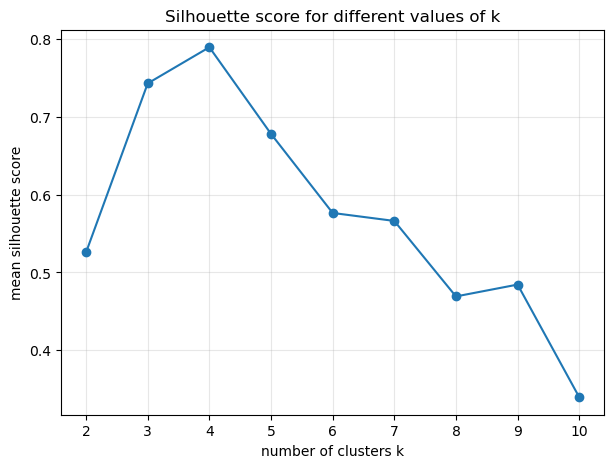

,k,silhouette_score
2,4,0.789786
1,3,0.743232
3,5,0.678290
4,6,0.576543
5,7,0.566287
0,2,0.525836
7,9,0.484394
6,8,0.469145
8,10,0.339462


In [6]:
ks = range(2, 11)
silhouette_scores = []

for k in ks:
    model = KMeans(n_clusters=k, n_init=5, max_iter=100, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_blobs_scaled)
    silhouette_scores.append(silhouette_score(X_blobs_scaled, labels))

plt.figure(figsize=(7, 5))
plt.plot(list(ks), silhouette_scores, marker="o")
plt.title("Silhouette score for different values of k")
plt.xlabel("number of clusters k")
plt.ylabel("mean silhouette score")
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({"k": list(ks), "silhouette_score": silhouette_scores}).sort_values(
    "silhouette_score", ascending=False
)

### Reflection

Compare elbow and silhouette:

1. Do they suggest the same `k`?
2. If not, which result would you trust more and why?
3. What would happen if the clusters were not round or equally dense?

## 6. K-Means limitation: non-spherical clusters

K-Means tends to work best when clusters are compact and approximately round. It can fail on curved or irregular shapes.

We test this with `make_moons`, which is a scikit-learn dataset generator.

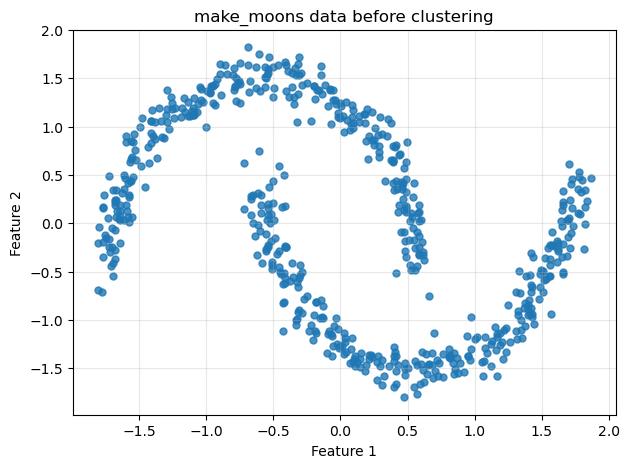

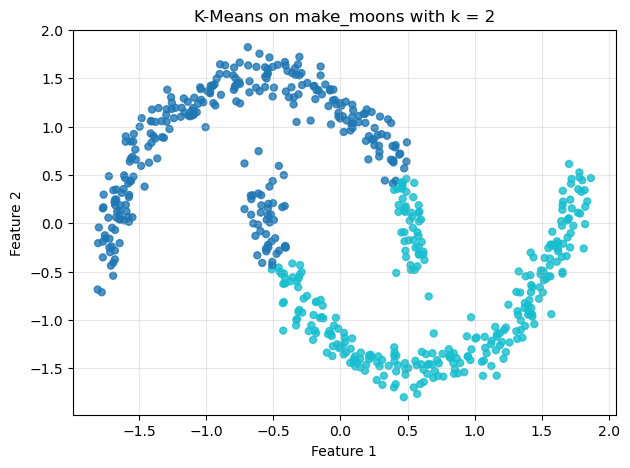

Adjusted Rand Index against hidden true labels, for teaching only: 0.466


In [7]:
X_moons, y_moons_true = make_moons(n_samples=600, noise=0.06, random_state=RANDOM_STATE)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

labels_kmeans_moons = KMeans(n_clusters=2, n_init=5, max_iter=100, random_state=RANDOM_STATE).fit_predict(X_moons_scaled)

plot_2d_clusters(X_moons_scaled, title="make_moons data before clustering")
plot_2d_clusters(X_moons_scaled, labels=labels_kmeans_moons, title="K-Means on make_moons with k = 2")

print("Adjusted Rand Index against hidden true labels, for teaching only:", round(adjusted_rand_score(y_moons_true, labels_kmeans_moons), 3))

### Interpretation

K-Means divides space around centroids. For curved data, the centroid assumption is not appropriate. This is why different clustering algorithms can capture different kinds of clusters.

## 7. DBSCAN: density-based clustering and outliers

DBSCAN defines clusters as dense regions. Unlike K-Means, it does not need `k` in advance.

Key parameters:

- `eps`: neighborhood radius;
- `min_samples`: minimum number of points required to form a dense region;
- label `-1`: noise / outlier points.

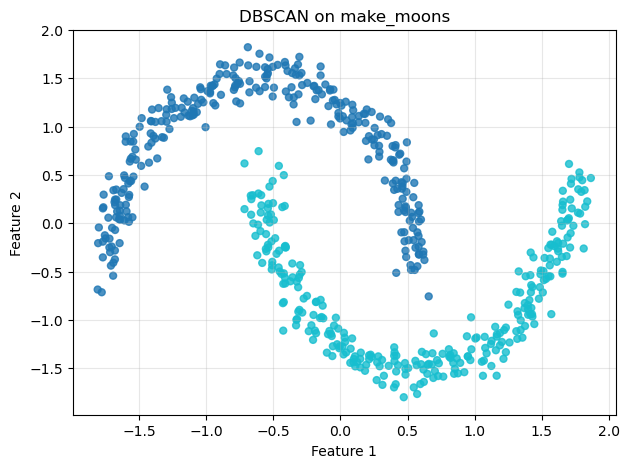

Number of clusters, ignoring noise: 2
Number of noise points: 0
Adjusted Rand Index against hidden true labels, for teaching only: 1.0


In [8]:
dbscan_moons = DBSCAN(eps=0.30, min_samples=5)
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons_scaled)

plot_2d_clusters(X_moons_scaled, labels=labels_dbscan_moons, title="DBSCAN on make_moons")

print("Number of clusters, ignoring noise:", count_clusters(labels_dbscan_moons))
print("Number of noise points:", count_noise(labels_dbscan_moons))
print("Adjusted Rand Index against hidden true labels, for teaching only:", round(adjusted_rand_score(y_moons_true, labels_dbscan_moons), 3))

## 8. DBSCAN parameter tuning

The most difficult DBSCAN parameter is often `eps`. A small `eps` may produce too many noise points; a large `eps` may merge separate clusters.

Run the cell and inspect how cluster count and noise count change.

In [9]:
rows = []
for eps in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.45, 0.60]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_moons_scaled)
    row = safe_internal_metrics(X_moons_scaled, labels)
    row["eps"] = eps
    row["ARI_teaching_only"] = adjusted_rand_score(y_moons_true, labels)
    rows.append(row)

pd.DataFrame(rows)[[
    "eps",
    "n_clusters_without_noise",
    "noise_points",
    "silhouette",
    "ARI_teaching_only",
]]

,eps,n_clusters_without_noise,noise_points,silhouette,ARI_teaching_only
0,0.10,15,50,0.105030,0.293316
1,0.15,2,13,0.399630,0.957070
2,0.20,2,3,0.393746,0.990017
3,0.25,2,2,0.391282,0.993333
4,0.30,2,0,0.386462,1.000000
5,0.35,2,0,0.386462,1.000000
6,0.45,1,0,NaN,0.000000
7,0.60,1,0,NaN,0.000000


### A practical eps diagnostic: k-distance plot

A common heuristic is to plot the distance to the `k`-th nearest neighbor, where `k = min_samples`. The bend in the sorted curve can suggest an `eps` value.

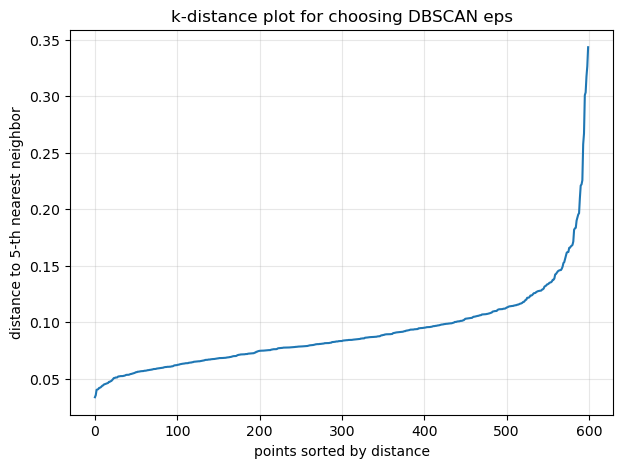

In [10]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_moons_scaled)
distances, indices = neighbors.kneighbors(X_moons_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances)
plt.title("k-distance plot for choosing DBSCAN eps")
plt.xlabel("points sorted by distance")
plt.ylabel(f"distance to {min_samples}-th nearest neighbor")
plt.grid(True, alpha=0.3)
plt.show()

### Task

Use the table and k-distance plot to choose another value for `eps`. Then rerun DBSCAN and compare:

- number of clusters;
- number of outliers;
- visual quality.

## 9. Optional: HDBSCAN if available

Some scikit-learn versions support `HDBSCAN`. It is related to DBSCAN but can handle clusters of varying density better and does not require choosing one fixed `eps`.

This cell safely skips HDBSCAN if it is not available in the local installation.

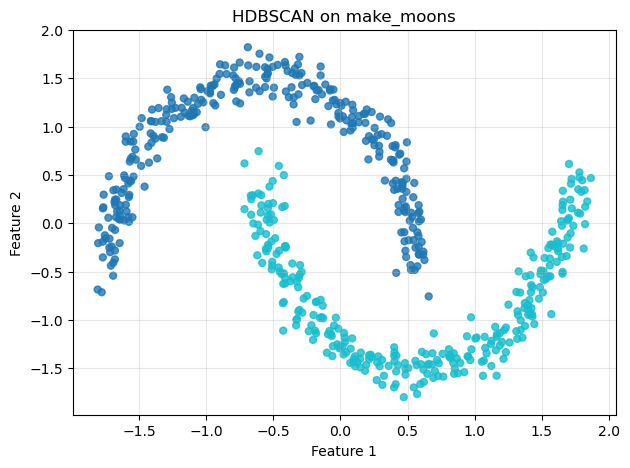

Number of clusters, ignoring noise: 2
Number of noise points: 0
ARI, teaching only: 1.0


In [11]:
if HAS_HDBSCAN:
    labels_hdbscan_moons = HDBSCAN(min_cluster_size=20, min_samples=5).fit_predict(X_moons_scaled)
    plot_2d_clusters(X_moons_scaled, labels=labels_hdbscan_moons, title="HDBSCAN on make_moons")
    print("Number of clusters, ignoring noise:", count_clusters(labels_hdbscan_moons))
    print("Number of noise points:", count_noise(labels_hdbscan_moons))
    print("ARI, teaching only:", round(adjusted_rand_score(y_moons_true, labels_hdbscan_moons), 3))
else:
    print("HDBSCAN is not available in this scikit-learn installation. Continue with the next section.")

## 10. Agglomerative Hierarchical Clustering

Agglomerative clustering is a bottom-up hierarchical method:

1. start with each point as its own cluster;
2. merge the closest clusters step by step;
3. stop when the desired number of clusters is reached.

Different linkage choices define "closest" differently. Here we start with Ward linkage, which is often a strong default for compact clusters.

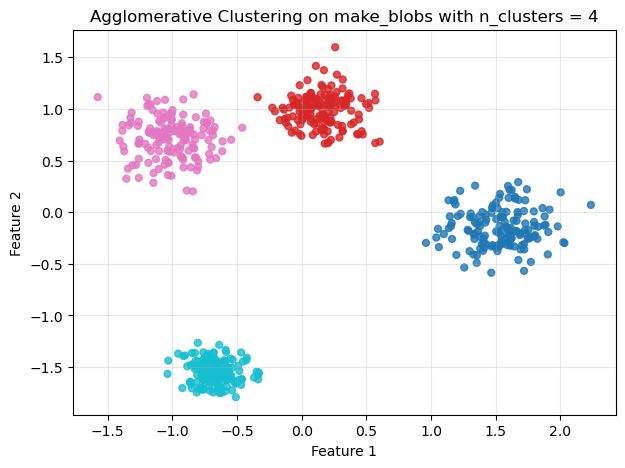

,n_clusters_without_noise,noise_points,silhouette,davies_bouldin,calinski_harabasz,model,adjusted_rand_index,normalized_mutual_info
0,4,0,0.789786,0.298535,6244.740756,Agglomerative(k=4),0.995548,0.992774


In [12]:
agg_4 = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg_4 = agg_4.fit_predict(X_blobs_scaled)

plot_2d_clusters(
    X_blobs_scaled,
    labels=labels_agg_4,
    title="Agglomerative Clustering on make_blobs with n_clusters = 4",
)

clustering_report(X_blobs_scaled, labels_agg_4, y_true=y_blobs_true, model_name="Agglomerative(k=4)")

### Dendrogram visualization

A dendrogram shows the sequence of merges. scikit-learn fits the hierarchical model, and SciPy is used only for the dendrogram drawing.

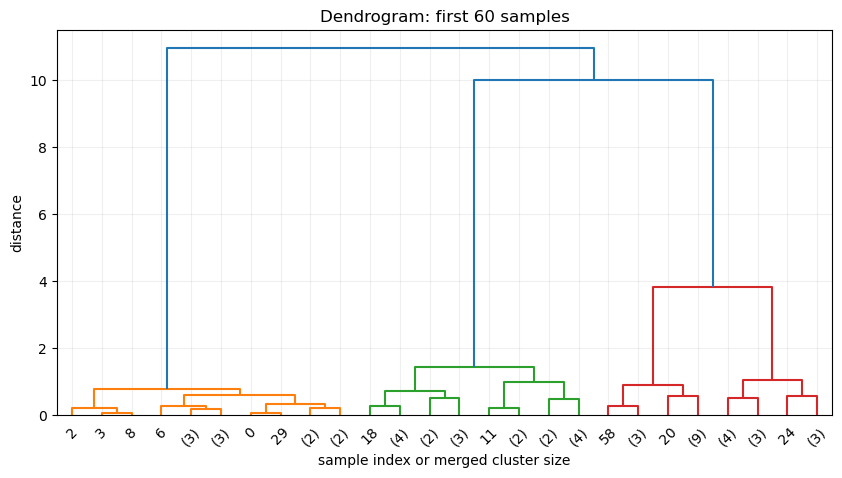

In [13]:
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    """Create linkage matrix from a fitted AgglomerativeClustering model and plot dendrogram."""
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts,
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

# Use a small sample to keep the dendrogram readable.
X_small = X_blobs_scaled[:60]
full_tree = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage="ward")
full_tree.fit(X_small)

plt.figure(figsize=(10, 5))
plt.title("Dendrogram: first 60 samples")
plot_dendrogram(full_tree, truncate_mode="level", p=4)
plt.xlabel("sample index or merged cluster size")
plt.ylabel("distance")
plt.grid(True, alpha=0.2)
plt.show()

### Task

Change the linkage method to `single`, `complete`, and `average` in `AgglomerativeClustering`. Compare the clustering plots and metric reports.

## 11. Compare algorithms on Iris

The Iris dataset is built into scikit-learn. It has 4 numerical features and 3 species labels.

For clustering, we hide the labels and fit the models only on the feature matrix. We use labels later only to evaluate and interpret the result.

In [14]:
iris = load_iris(as_frame=True)
X_iris_df = iris.data
X_iris = X_iris_df.to_numpy()
y_iris = iris.target.to_numpy()

X_iris_scaled = StandardScaler().fit_transform(X_iris)

print("Feature names:", list(X_iris_df.columns))
print("Target names, used only for evaluation:", list(iris.target_names))
print("X shape:", X_iris_scaled.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names, used only for evaluation: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
X shape: (150, 4)


In [15]:
models = {
    "KMeans(k=3)": KMeans(n_clusters=3, n_init=5, max_iter=100, random_state=RANDOM_STATE),
    "DBSCAN(eps=0.85)": DBSCAN(eps=0.85, min_samples=5),
    "Agglomerative(k=3)": AgglomerativeClustering(n_clusters=3, linkage="ward"),
}

if HAS_HDBSCAN:
    models["HDBSCAN"] = HDBSCAN(min_cluster_size=10, min_samples=5)

reports = []
labels_by_model = {}

for name, model in models.items():
    labels = model.fit_predict(X_iris_scaled)
    labels_by_model[name] = labels
    reports.append(clustering_report(X_iris_scaled, labels, y_true=y_iris, model_name=name))

comparison_df = pd.concat(reports, ignore_index=True)
comparison_df[[
    "model",
    "n_clusters_without_noise",
    "noise_points",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "adjusted_rand_index",
    "normalized_mutual_info",
]].sort_values("silhouette", ascending=False)

,model,n_clusters_without_noise,noise_points,silhouette,davies_bouldin,calinski_harabasz,adjusted_rand_index,normalized_mutual_info
1,DBSCAN(eps=0.85),2,4,0.597941,0.568802,277.650960,0.551755,0.689979
3,HDBSCAN,2,2,0.589917,0.584899,266.350386,0.563751,0.717464
0,KMeans(k=3),3,0,0.459948,0.833595,241.904402,0.620135,0.659487
2,Agglomerative(k=3),3,0,0.446689,0.803467,222.719164,0.615323,0.675470


### Visualize high-dimensional Iris data with PCA

PCA reduces the 4-dimensional Iris features to 2 dimensions for visualization only. The clustering is still fitted on the scaled 4-dimensional data above.

Explained variance ratio of the first two PCA components: [0.73  0.229]


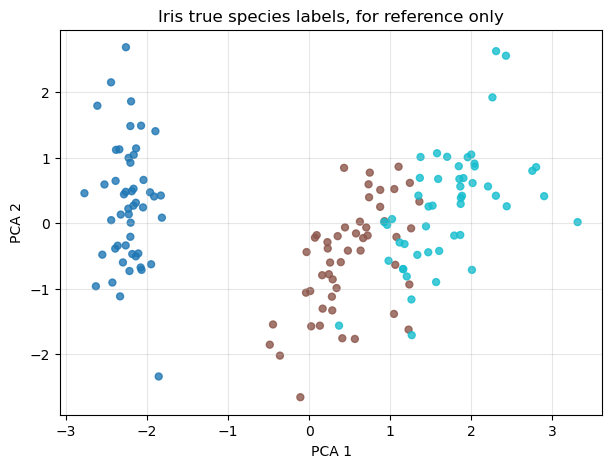

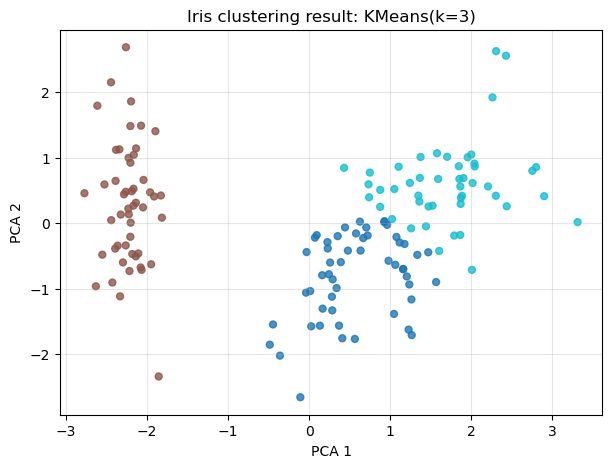

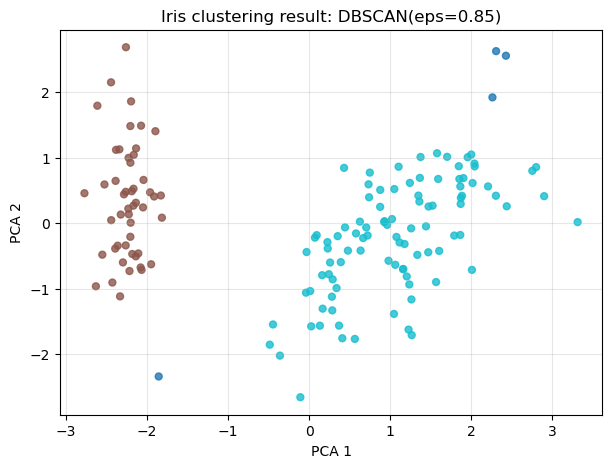

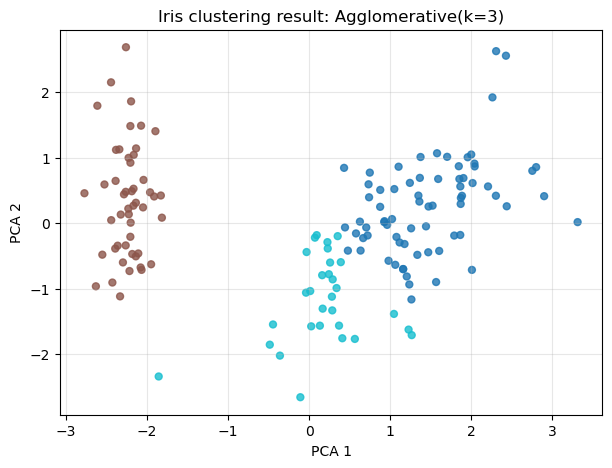

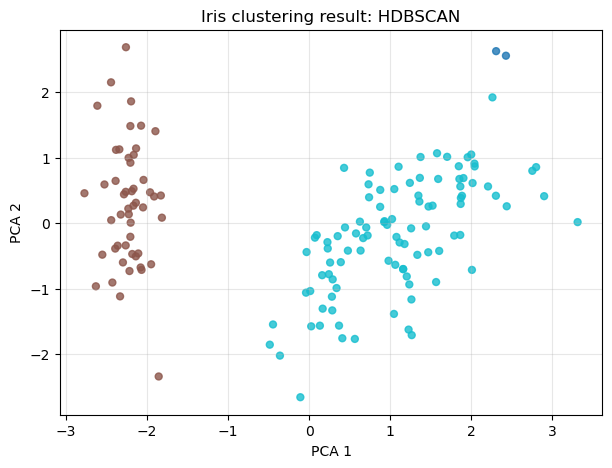

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_iris_pca = pca.fit_transform(X_iris_scaled)
print("Explained variance ratio of the first two PCA components:", np.round(pca.explained_variance_ratio_, 3))

plot_2d_clusters(X_iris_pca, labels=y_iris, title="Iris true species labels, for reference only", xlabel="PCA 1", ylabel="PCA 2")

for name, labels in labels_by_model.items():
    plot_2d_clusters(X_iris_pca, labels=labels, title=f"Iris clustering result: {name}", xlabel="PCA 1", ylabel="PCA 2")

### Reflection

1. Which metric prefers which model?
2. Are internal metrics and external metrics always aligned?
3. Why should we not use true labels while fitting an unsupervised clustering model?

## 12. Application: customer segmentation with synthetic data

The lecture mentions customer segmentation as a typical clustering use case. Here we create a synthetic customer dataset with two features:

- annual income in thousand euros;
- spending score from 0 to 100.

This is not a real customer dataset, but it demonstrates the end-to-end workflow.

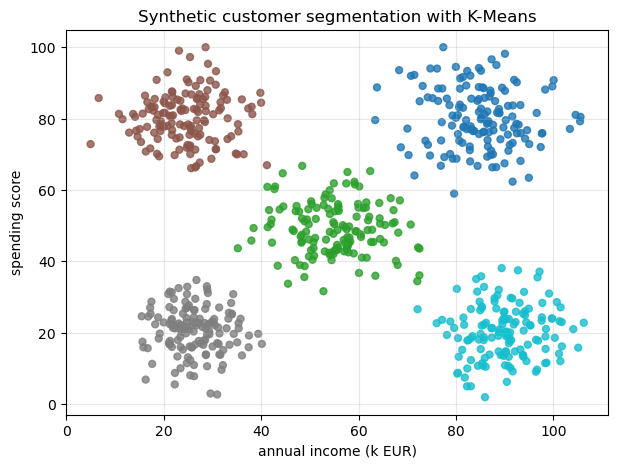

,n_customers,mean_income_k_eur,mean_spending_score
segment,,,
2,140,24.5,80.2
3,140,26.3,20.6
1,139,55.2,49.1
0,142,84.9,80.1
4,139,90.1,20.2


In [17]:
customer_centers = np.array([
    [25, 80],   # lower income, high spending
    [55, 50],   # middle group
    [85, 80],   # high income, high spending
    [25, 20],   # lower income, low spending
    [90, 20],   # high income, low spending
])

X_customers, _ = make_blobs(
    n_samples=700,
    centers=customer_centers,
    cluster_std=[7, 8, 8, 6, 7],
    random_state=RANDOM_STATE,
)

customers = pd.DataFrame(X_customers, columns=["annual_income_k_eur", "spending_score"])
customers["annual_income_k_eur"] = customers["annual_income_k_eur"].clip(5, 140)
customers["spending_score"] = customers["spending_score"].clip(0, 100)

X_customers_scaled = StandardScaler().fit_transform(customers)
customer_model = KMeans(n_clusters=5, n_init=5, max_iter=100, random_state=RANDOM_STATE)
customers["segment"] = customer_model.fit_predict(X_customers_scaled)

plot_2d_clusters(
    customers[["annual_income_k_eur", "spending_score"]].to_numpy(),
    labels=customers["segment"].to_numpy(),
    title="Synthetic customer segmentation with K-Means",
    xlabel="annual income (k EUR)",
    ylabel="spending score",
)

customers.groupby("segment").agg(
    n_customers=("segment", "size"),
    mean_income_k_eur=("annual_income_k_eur", "mean"),
    mean_spending_score=("spending_score", "mean"),
).round(1).sort_values("mean_income_k_eur")

### Student task

Give each segment a business-friendly name, for example:

- budget cautious;
- high-value customers;
- premium but low engagement;
- young / exploratory buyers.

Then propose one marketing action for each segment.

## 13. Application: anomaly detection using clustering

The lecture describes anomaly detection as finding points with low affinity to all clusters.

Here we compare two practical approaches:

1. K-Means distance-based anomalies: points far from all centroids;
2. DBSCAN noise points: points labeled as `-1`.

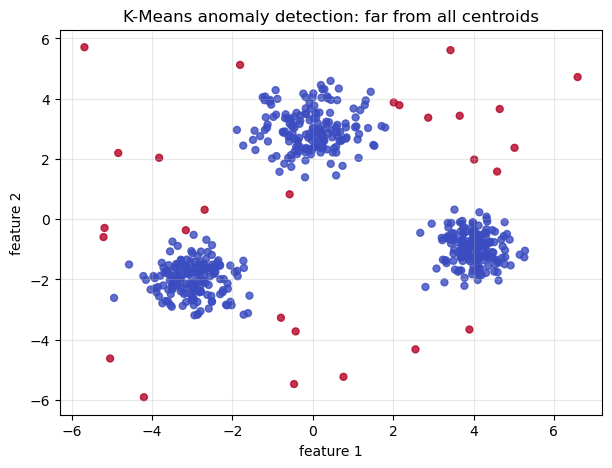

K-Means flagged anomalies: 27
Distance threshold: 0.721


In [18]:
X_normal, _ = make_blobs(
    n_samples=500,
    centers=np.array([[-3, -2], [0, 3], [4, -1]]),
    cluster_std=[0.6, 0.7, 0.5],
    random_state=RANDOM_STATE,
)
rng = np.random.default_rng(RANDOM_STATE)
X_outliers = rng.uniform(low=[-7, -6], high=[7, 6], size=(30, 2))
X_anomaly = np.vstack([X_normal, X_outliers])
X_anomaly_scaled = StandardScaler().fit_transform(X_anomaly)

km_anomaly = KMeans(n_clusters=3, n_init=5, max_iter=100, random_state=RANDOM_STATE)
km_labels = km_anomaly.fit_predict(X_anomaly_scaled)
dist_to_nearest_centroid = km_anomaly.transform(X_anomaly_scaled).min(axis=1)
threshold = np.percentile(dist_to_nearest_centroid, 95)
km_is_anomaly = dist_to_nearest_centroid > threshold

plt.figure(figsize=(7, 5))
plt.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c=km_is_anomaly, s=25, cmap="coolwarm", alpha=0.8)
plt.title("K-Means anomaly detection: far from all centroids")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.grid(True, alpha=0.3)
plt.show()

print("K-Means flagged anomalies:", int(km_is_anomaly.sum()))
print("Distance threshold:", round(threshold, 3))

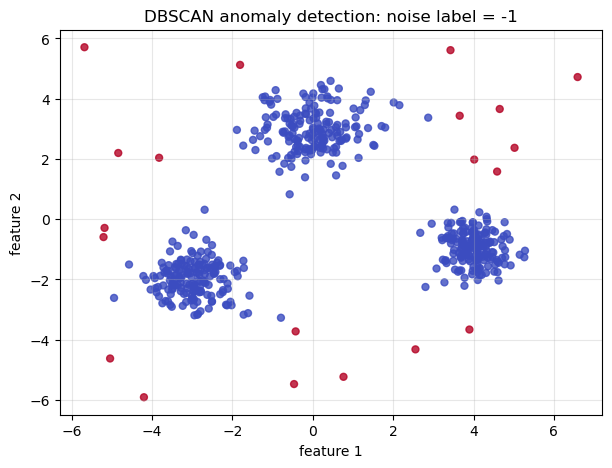

DBSCAN clusters, ignoring noise: 3
DBSCAN flagged anomalies: 20


In [20]:
db_anomaly = DBSCAN(eps=0.35, min_samples=8)
db_labels_anomaly = db_anomaly.fit_predict(X_anomaly_scaled)
db_is_anomaly = db_labels_anomaly == -1

plt.figure(figsize=(7, 5))
plt.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c=db_is_anomaly, s=25, cmap="coolwarm", alpha=0.8)
plt.title("DBSCAN anomaly detection: noise label = -1")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.grid(True, alpha=0.3)
plt.show()

print("DBSCAN clusters, ignoring noise:", count_clusters(db_labels_anomaly))
print("DBSCAN flagged anomalies:", int(db_is_anomaly.sum()))